# Sign Language Interpreter
This is the final project for CSCA 5642 Introduction to Deep Learning from UC Boulder's Masters of Science in AI program. The goal is to use a CNN (Convolutional Neural Network) to predict the number (0 through 9) represented by a hand gesture in an image using ASL (American Sign Language). I want to explore the accuracy of a CNN and determine if it would be a useful foundation for future, more ambitious projects, such as processing video frames to interpret a person signing more advanced language.

Kaggle Notebook: https://www.kaggle.com/code/keithpatton101/sign-language-interpreter

GitHub Repo: https://github.com/kpjava/sign-language-interpreter


## Data
Arda Mavi. (2017). Sign Language Digits Dataset [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/11071

I used the Kaggle *Sign Language Digits Dataset* for this project. The dataset has two files, **X.npy** and **Y.npy** which are numpy files. 

**X.npy** (33.78 MB) contains 2,062 the grayscale images (64x64) representing human hands signing a digit 0 through 9 in ASL, the American Sign Language.

**Y.npy** (165 kB) contains labels for the digits 0 through 9 to correlate the proper number with each image.

### Data Exploration

I'll load both files and inspect **X_np** first.

In [60]:
import numpy as np

data_dir = '/kaggle/input/datasets/ardamavi/sign-language-digits-dataset'
X_np = np.load(f'{data_dir}/X.npy')
y_np = np.load(f'{data_dir}/Y.npy')

print('Data successfully loaded X.npy and Y.npy.')
print(f'\nX_np => Array type: {X_np.dtype}, Shape: {X_np.shape}')

Data successfully loaded X.npy and Y.npy.

X_np => Array type: float32, Shape: (2062, 64, 64)


#### The Type and Shape of X_np
`X_np` is a nested array of float32 values that contains 2,062 separate 64x64 images. Rather than image files, this format specifies the pixels directly in a numpy `ndarray`. Each entry represents the grayscale pixels as we will see in a moment.

CNNs expect images to have 1 to 3 dimensions for color channels (1 = Grayscale, 3 = RGB). Therefore, I will have to add an extra dimension to change the shape to (2062, 64, 64, 1)


In [61]:
X = np.expand_dims(X_np, axis=-1)
print(f'\nX => Array type: {X.dtype}, Shape: {X.shape}')


X => Array type: float32, Shape: (2062, 64, 64, 1)


In [62]:
print(f'\nSome sample pixels of the first image\n{"-"*80}')
print(X_np[0])


Some sample pixels of the first image
--------------------------------------------------------------------------------
[[0.46666667 0.4745098  0.47843137 ... 0.5176471  0.5137255  0.5019608 ]
 [0.49803922 0.4862745  0.4862745  ... 0.5254902  0.5176471  0.50980395]
 [0.54509807 0.49411765 0.49019608 ... 0.5294118  0.5254902  0.5137255 ]
 ...
 [0.5019608  0.5137255  0.5176471  ... 0.5529412  0.54509807 0.53333336]
 [0.49803922 0.5058824  0.5137255  ... 0.54509807 0.53333336 0.52156866]
 [0.49019608 0.49803922 0.5019608  ... 0.5294118  0.52156866 0.50980395]]


The pixel values look apprpriately scaled beteween 0 and 1, so no additional work is required to analyze the images in a CNN.

I will show sample images in the later section, Exploratory Data Analysis, to make sure the pixel data does indeed represent an image.

#### The Type and Shape of y_np

`y_np` is a nested array of float64 values, which is surprising. I assumed the values would represent labels for each image and only indicate a single digit 0 through 9. I'm not sure why it isn't simply an array of integers, but let's inspect it to learn a little more.

In [63]:
print(f'y_np => Array type: {y_np.dtype}, Shape: {y_np.shape}')
print('\nThe first 3 entries:')
print(y_np[:3])
print('\nThe last 3 entries:')
print(y_np[-6:-3])

y_np => Array type: float64, Shape: (2062, 10)

The first 3 entries:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

The last 3 entries:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


The home page of the kaggle dataset doesn't explain the format of this file, but it appears to be a set of one-hot encoded values rather than simple integers.

## Data Cleaning
No actual cleaning is required (e.g., removing images). Fortunately, the number of labels corresponds to the number of images. 

For my analysis purposes, I will convert the labeled data into an array of integers (0..9).

In [64]:
y = np.argmax(y_np, axis=1)
print('Converted one-hot encoding to integers 0..9')
print('\nThe first 3 entries:', y[:3])
print('The last 3 entries:', y[-6:-3])

Converted one-hot encoding to integers 0..9

The first 3 entries: [0 0 0]
The last 3 entries: [9 9 9]


## Exploratory Data Analysis (EDA)
The next task is to look at a few images for each number label to make sure there are no surprises. I expect each value in **y** to correspond to the proper ASL image.

I'll write a utility function to scan for 4 particular values (e.g., all threes) and return their indexes. That way, I can make sure to display the expected images in the proper order.

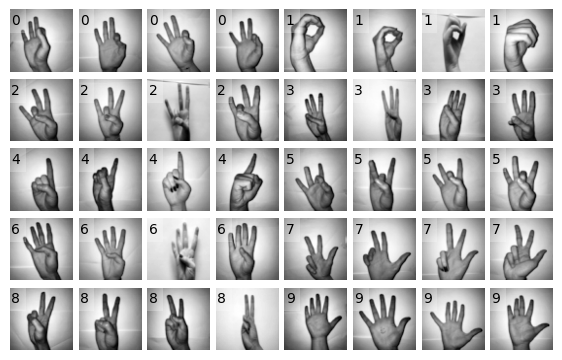

In [65]:
# utility functions
import matplotlib.pyplot as plt

def find_indexes_of_value(a, value, n=1):
    """Return {n} indexes in array, {a} that contain {value}"""
    return np.flatnonzero(a == value)[:n]

def plot_samples(X, y):
    """Plot the first four images (with labels) of each ASL number"""
    fig, axs = plt.subplots(nrows=5, ncols=8, figsize=(7, 4.5))

    # Loop through each ASL digit 0..9
    for value in range(10):
        indexes = find_indexes_of_value(y, value, 4)

        # Print 4 images of each value, two sets per row
        # For instance 0, 0, 0, 0, 1, 1, 1, 1 <\n> 2, 2, 2, 2, 3, 3, etc.
        for col, idx in enumerate(indexes):
            row = value // 2
            ax = axs[row, col + (4 * (value % 2))]
            ax.imshow(X[idx], cmap='gray')

            # Print the label overlaid on the image so we can see more images in one glance
            ax.text(1, 15, y[idx], bbox=dict(edgecolor='none', facecolor='#FFFFFF40'))
            ax.axis('off')

    plt.subplots_adjust(wspace=0.1, hspace=0.02)
    plt.show()

plot_samples(X, y)

#### Problem
Unfortunately, my assumption that each one-hot-encoded value from **y_np** represented the correct ASL digit was wrong. The value labels do not match the corresponding ASL images. The good news is that they are consistent, and each label does correspond to images of the same hand configuration.

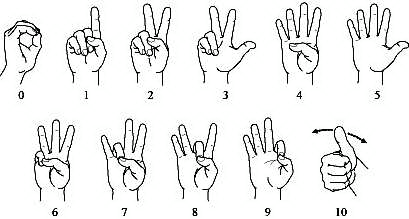

#### Solution
It appears that the labels are the result of an earlier unsupervised machine learning exercise, giving them consistent labels but not having anything to do with the correct ASL digit. Since they are consistent, I can use a lookup table to translate the labels to the correct ASL digit.
The necessary lookup table is [9, 0, 7, 6, 1, 8, 4, 3, 2, 5]. 

I will convert `y` by swapping each value with the correct number and store it in `y_fixed`.
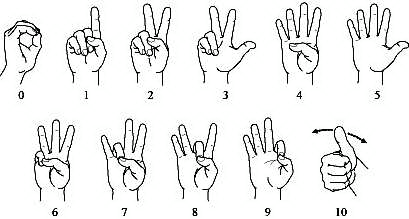

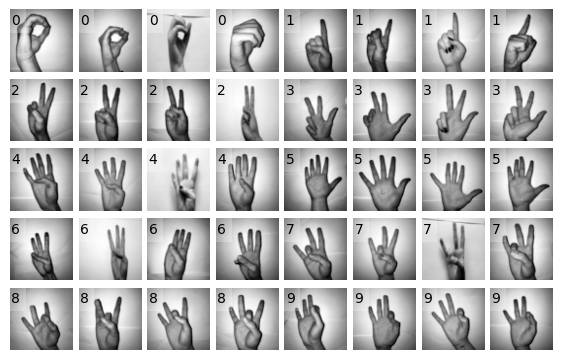

In [66]:
y_fixed = np.array([9, 0, 7, 6, 1, 8, 4, 3, 2, 5])[y]
plot_samples(X, y_fixed)

Much better! Every image is now visually correlated with the correct ASL digit.

### EDA Conclusion
I now understand the intention of the **Y.np** file and have converted one-hot-encoded values, and looked them up to align them with the correct ASL number.

In addition, I added a monochrome color dimension to the **X.np** array to accommodate analysis by a CNN.

I am now ready to use these images and proper target values to train and validate some models.

## Models
For this project, I have chosen a Convolutional Neural Network using TensorFlow's Keras library.

The model consists of 9 layers, with 2 convolutional layers. Let me break down what each model is intended to do:
1. **Input Layer**: This layer will create a neuron for each pixel of the 64x64 grayscale image.

2. **Convolution Layer**: This layer will use 32 neurons and a grid size of 3x3. While training, this layer will identify simple features like edges, curves and lines. The layer will use `relu` activation to disregard negative data.

3. **Max Pooling Layer**: This special layer will downsample the neurons analyzed so far to generalize and increase the efficiency of calculations that will happen later. It will keep only the strongest pixel in every 2x2 area.

4. **Convolution Layer**: This layer uses 64 neurons and a grid size of 3x3. Its purpose is to generalize features leveraged by the earlier convolution (e.g., changing finger edges into fingers).

5. **Max Pooling Layer**: Another pooling layer to downsample.

6. **Flatten Layer**: This layer will take the spatial information from all prior layers and convert it a flat list of numerical information.

7. **Dense Layer**: This is the hidden layer with 128 neurons that draws conclusions. For instance, if it sees 4 long vertical lines and a tucked thumb, it might be the number 4.

8. **Dropout**: This layer tries to minimize overfitting and randomly drops 30% of the neurons from earlier steps. This prevents the model from simply memorizing the image training data.

9. **Dense Layer**: The final layer has 10 neurons and a `softmax` activation, where each neuron is a one-hot-encoding for the probability that the image is a digit 0 through 9.

In [86]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_sign_language_model():
    """
    Build a CNN to analyze grayscale images 64x64x1
    """
    model = models.Sequential([
        layers.Input(shape=(64, 64, 1)),
        
        layers.Conv2D(32, (3, 3), activation='relu', name='conv_layer_1'),
        layers.MaxPooling2D((2, 2)),  # reduce image size to concentrate on larger features
        
        layers.Conv2D(64, (3, 3), activation='relu', name='conv_layer_2'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),                   # reduce chances of overfitting
        layers.Dense(10, activation='softmax') # 10 classes for digits 0-9
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_sign_language_model()

### Model Training

The next step is to split the images and labels into training and validation sets and then **fit** the model by analyzing the training images, and adjusting the weights to correct for mis-labeling.

In [87]:
from sklearn.model_selection import train_test_split

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y_fixed, test_size=0.2, random_state=42)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.1566 - loss: 2.2877 - val_accuracy: 0.4867 - val_loss: 1.6711
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.5278 - loss: 1.4626 - val_accuracy: 0.7676 - val_loss: 0.7393
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7391 - loss: 0.8309 - val_accuracy: 0.7918 - val_loss: 0.7008
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7513 - loss: 0.7539 - val_accuracy: 0.8160 - val_loss: 0.5335
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7992 - loss: 0.5887 - val_accuracy: 0.8426 - val_loss: 0.5174
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.8213 - loss: 0.5213 - val_accuracy: 0.8426 - val_loss: 0.4436
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.8544 - loss: 0.4320 - val_accuracy: 0.8741 - val_loss: 0.3979
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8868 - loss: 0.3362 - val_accuracy: 0.8571 - v

### Model Fitting Results

The accuracy (98%) is pretty impressive after only 20 epochs, requiring only 86 seconds on the kaggle server. 

Next, I'll write a few utility functions to display a sample images, the prediction, and the model's probabilities that helped it determine the prediction. I can then test out the model a few times manually and verify the accuracy myself.

In [104]:
def plot_prediction_results(X, y, idx, model):
    """
    Plot an image, a prediction, whether the prediction was True and
    the probabilities in a subplot side by side
    """
    image = X[idx]
    true_label = y[idx]
    prediction = model.predict(np.expand_dims(image, axis=0))
    
    # Create a figure with two side-by-side subplots
    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(10, 4))

    # Left Cell: The Image
    ax_img.imshow(image.squeeze(), cmap='gray')
    ax_img.set_title(f"Sample Image X[{idx}]")
    ax_img.axis('off')

    # Right Cell: The 10 Probabilities
    text_lines = []
    for i, p in enumerate(prediction.squeeze()):
        text_lines.append(f"Class {i}: {p*100:>6.2f}%") # Class 3: 85.2%
    
    # Display text using relative coordinates (0 to 1)
    summary_text = "Probabilities:\n\n" + "\n".join(text_lines)
    ax_txt.text(0.1, 0.95, summary_text, 
                fontsize=14, 
                verticalalignment='top',
                family='monospace', # Keeps the numbers aligned
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    # The ASL number is the index of the maximum probability
    predicted_label = np.argmax(prediction)
    ax_txt.axis('off')
    plt.tight_layout()
    plt.show()

    # Tell the viewer what was expected and if the prediction was correct
    success_txt = 'YES!' if predicted_label == true_label else 'NO!'
    print(f"Is the prediction ({predicted_label}) correct? {success_txt}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


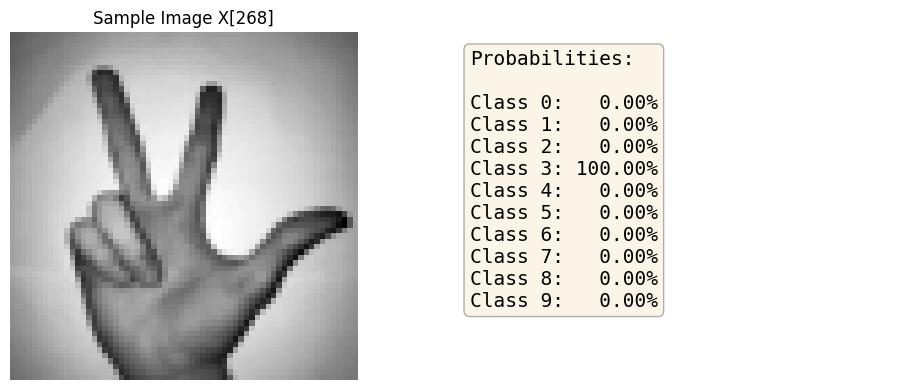

Is the prediction (3) correct? YES!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


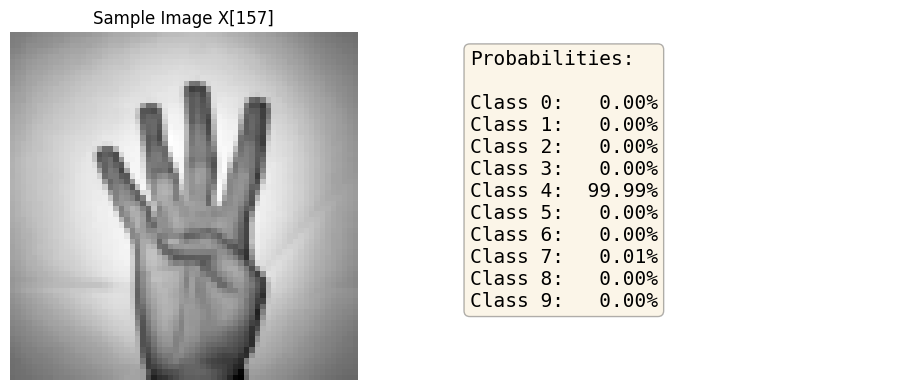

Is the prediction (4) correct? YES!



In [105]:
plot_prediction_results(X_val, y_val, 268, model)
plot_prediction_results(X_val, y_val, 157, model)

As you can see from the two samples above, the softmax prediction is working very well and properly identifying the correct ASL digit.

## Conclusion
In this project, I completed the following activities:
* I used a kaggle dataset of hand images representing the ASL (American Sign Language) numbers 0 through 9.

* During EDA, I explored the two datasets, **X.np** and **Y.np** to understand the formats and massaged them as necessary.

* I fixed the labels with a lookup table so that a CNN (Convolutional Neural Network) could accurately match the image to the proper digit.

* I trained the CNN and achieved 98% accuracy after 20 epochs.

* I wrote utility functions to show a few samples and the predicted probabilities to show us what the model was calculating

#### Next Steps
If the model had not been so accurate, my next step would have been to start tweaking the model architecture, or hypertuning anything to improve the results, or even choosing an entirely different model type. 

I've read that CNNs are old school. In the future, I will experiment with **ViT**s (Vision Transformers) with this type of data to see the strengths and weaknesses compared to CNNs.

However, since things turned out so well in the first iteration, I will concentrate on understanding why it worked so well.

## EXTRA - What did the CNN Actually "Learn"?
All credit for the following section goes to Google Gemini for showing me how to visualize what the CNN truly learned and if the accuracy was a fluke, or if the CNN model showed some actual learning of abstract visual features. 

I worked with Gemini below to implement a **Grad-CAM** (Gradient-weighted Class Activation Mapping). The goal was to see what the model was focusing on and highlight specific visual patterns that led to a prediction.

### How the Heatmap was Built
The heatmap was generated by following a specific mathematical pipeline:

* **Targeting the Class**: We first perform a forward pass with an image (like the ASL "4") to see which class the model predicts.

* **Calculating Gradients**: We use a tf.GradientTape to calculate the gradient of the predicted class score with respect to the feature maps of the final convolutional layer.

* **Weighting Features**: We "pool" these gradients to determine the importance of each individual filter in that layer.

* **Combining and Normalizing**: We multiply the importance weights by the layer's output, sum them up, and apply a ReLU to keep only the features that have a positive influence on the prediction.

* **Superimposition**: Finally, we upscale this 2D grid to the original image size (64x64) and overlay it using a "Jet" colormap for easy visualization.

### Why the Last Convolutional Layer was Targeted
We specifically looked at `conv_layer_2` because it is the "bridge" between visual patterns and abstract concepts:

* **Spatial Information**: Unlike Dense (Fully Connected) layers, which flatten data into a list of numbers, convolutional layers preserve the 2D spatial arrangement of the image.

* **High-Level Features**: While early layers look for simple edges, the last convolutional layer captures complex, class-specific shapes like finger joints, palm curves, and finger counts. This layer contains the most sophisticated visual information before the model discards spatial coordinates to make a final classification.

In [102]:
# Google Gemini helped write these functions to build and display the Grad-CAM
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

last_conv_layer_name = "conv_layer_2"

def make_gradcam_heatmap(img_array, model):
    """Build Grad-CAM heatmap by analyzing the model in action"""
    last_conv_layer = model.get_layer(last_conv_layer_name)
    
    # Define a mini-function that handles the internal activations
    @tf.function
    def get_activations_and_grads(inputs):
        with tf.GradientTape() as tape:
            # We track the output of the convolutional layer
            # We manually iterate through the Sequential layers to get here
            x = inputs
            conv_output = None
            for layer in model.layers:
                x = layer(x)
                if layer.name == last_conv_layer_name:
                    conv_output = x
            
            predictions = x # This is the final output
            pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
            
        return conv_output, tape.gradient(class_channel, conv_output)

    # 3. Run the manual pass
    last_conv_layer_output, grads = get_activations_and_grads(img_array)

    # 4. Compute mean intensity of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Calculate heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    """Display the Grad-CAM heatmap"""
    jet = plt.colormaps["jet"]

    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to match image size
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose (ensure both are RGB for the overlay)
    # If input is grayscale, stack it to 3 channels
    if img.shape[-1] == 1:
        img = np.concatenate([img, img, img], axis=-1)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    fig, (ax_orig, ax_heatmap) = plt.subplots(1, 2, figsize=(10, 4))
    ax_orig.imshow(img.squeeze(), cmap='gray')
    ax_orig.axis('off')
    
    ax_heatmap.imshow(superimposed_img)
    ax_heatmap.axis('off')
    plt.show()

def evaluate_image_heatmap(idx):
    """Evaluate and display a Grad-CAM heatmap for a specific index"""
    img_for_display = X_val[idx]
    heatmap = make_gradcam_heatmap(X_val[idx:idx+1], model)
    display_gradcam(img_for_display, heatmap)

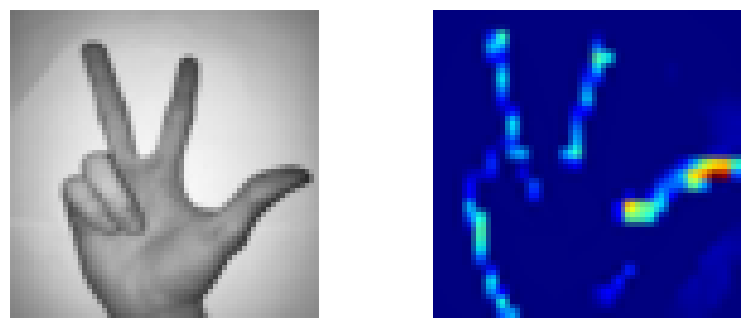

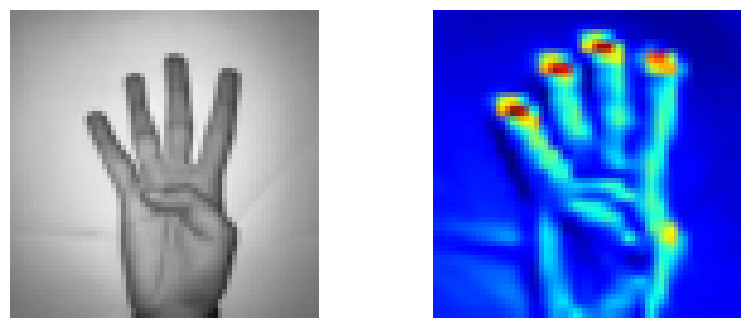

In [103]:
evaluate_image_heatmap(268)
evaluate_image_heatmap(157)

### What the Heatmap Represents
The heatmap is a visual map of Model Attention:

* **Importance**: Red and orange areas indicate "hot" regions that the model found highly relevant for its choice. A very interesting fact is that each time I fit the model, I get different heatmaps for the same images, indicating that random weight adjustments end up focusing on different high-level features.

* **Logic Verification**: It proves the model is using actual hand geometry (like the gaps between fingers or the position of the thumb) rather than "cheating" by looking at background shadows or wrist artifacts.

* **Explainability**: It transforms a "black box" neural network into an interpretable tool, confirming that the 98% accuracy is based on legitimate features of the hand and fingers, and whether the thumb should be considered or ignored.